# 🧪 A/B Testing — Discount Impact Analysis

## 🎯 Objective
Evaluate whether discounts improve:
- Conversion rate (order completion)
- Order value (revenue)
- Repeat purchase behavior

## 🧠 Experiment Design
- Group A (Control): discount_pct = 0  
- Group B (Treatment): discount_pct > 0  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency

df = pd.read_csv("clean_data_full.csv")

In [2]:
df.head()

,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,...,order_month,order_weekday,delivery_delay,is_late_delivery,first_order_date,customer_lifetime_days,has_discount,discount_value,discount_category,delay_category
0,ORD0000001,CUST010401,REST0487,Radhakrishnan Ltd Kitchen,2024-06-12 21:47:00,Bengaluru,Rolls & Wraps,127.12,5,6.36,...,2024-06,2,118.0,True,2023-01-24 16:01:00,505,True,6.36,0-10%,NaN
1,ORD0000002,CUST007934,REST0116,"Bera, Narula and Sridhar Kitchen",2023-11-04 20:56:00,Mumbai,Rolls & Wraps,144.27,10,14.43,...,2023-11,5,50.0,True,2023-03-22 21:28:00,226,True,14.43,0-10%,Slow
2,ORD0000003,CUST007327,REST0361,"Nayak, Mann and Thaker Kitchen",2024-03-11 08:29:00,Bengaluru,Desserts,241.70,25,60.42,...,2024-03,0,46.0,True,2023-01-25 10:37:00,410,True,60.42,20-50%,Slow
3,ORD0000004,CUST011260,REST0180,Chahal Inc Kitchen,2023-10-02 16:56:00,Mumbai,Biryani,537.42,10,53.74,...,2023-10,0,128.0,True,2023-01-05 13:41:00,270,True,53.74,0-10%,NaN
4,ORD0000005,CUST004397,REST0152,"Khatri, Bhatia and Mutti Kitchen",2023-12-14 18:02:00,Mumbai,Rolls & Wraps,147.87,15,22.18,...,2023-12,3,48.0,True,2023-05-14 01:40:00,214,True,22.18,10-20%,Slow


 ## 1.CONVERSION (CHI-SQUARE)

In [3]:
group_A = df[df['has_discount'] == False]
group_B = df[df['has_discount'] == True]

completed_A = (group_A['order_status'] == 'Delivered').sum()
cancelled_A = (group_A['order_status'] != 'Delivered').sum()

completed_B = (group_B['order_status'] == 'Delivered').sum()
cancelled_B = (group_B['order_status'] != 'Delivered').sum()





In [7]:
from scipy import stats

contingency = [[completed_A, cancelled_A],
               [completed_B, cancelled_B]]

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("Chi2:", chi2)
print("P-value:", p)

Chi2: 0.3365449133818851
P-value: 0.5618303852883981


In [21]:
 if p < 0.05:
    print("Reject H0 → Discount improves conversion")
else:
    print("Fail to reject H0 → No significant effect")

Fail to reject H0 → No significant effect



## 💡 Insight

👉
“Discounts do not significantly improve order completion rate, indicating that operational factors may be more critical than pricing incentives.”

 ##  TEST 2 — ORDER VALUE (T-TEST)

H0: Order value is same for discount vs non-discount  
H1: Discount increases order value  

In [24]:
from scipy.stats import ttest_ind

group_A = df[df['has_discount'] == False]['order_value']
group_B = df[df['has_discount'] == True]['order_value']

t_stat, p_val = ttest_ind(group_B, group_A, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: -1.4082492074678519
P-value: 0.15906124158384735


In [25]:
if p_val < 0.05:
    print("Reject H0 → Discount impacts order value")
else:
    print("Fail to reject H0 → No significant difference")

Fail to reject H0 → No significant difference


 ## 💡 Insight

👉
“Discounts do not significantly increase order value, suggesting limited impact on short-term revenu

 ## TEST 3 — REPEAT PURCHASE (CHI-SQUARE)

H0: Discount does NOT affect repeat purchase  
H1: Discount increases repeat purchase  

In [26]:
repeat = df.groupby('customer_id').agg({
    'order_id':'count',
    'has_discount':'max'
}).reset_index()

repeat['is_repeat'] = repeat['order_id'] > 1

table = pd.crosstab(repeat['has_discount'], repeat['is_repeat'])

chi2, p_repeat, _, _ = stats.chi2_contingency(table)

print("P-value:", p_repeat)

P-value: 1.3470827912688097e-146


In [27]:
if p_repeat < 0.05:
    print("Reject H0 → Discount improves repeat purchase")
else:
    print("Fail to reject H0 → No significant effect")

Reject H0 → Discount improves repeat purchase


 ## 💡 Insight

👉
“Discounts can improve repeat purchase behavior, indicating stronger impact on retention than acquisition.”

## TEST 4 — ANOVA (DISCOUNT LEVEL IMPACT)

H0: No difference in order value across discount categories  
H1: At least one discount category differs  

In [29]:
g1 = df[df['discount_category']=='No Discount']['order_value']
g2 = df[df['discount_category']=='0-10%']['order_value']
g3 = df[df['discount_category']=='10-20%']['order_value']
g4 = df[df['discount_category']=='20-50%']['order_value']

f_stat, p_anova = f_oneway(g1, g2, g3, g4)

print("F-stat:", f_stat)
print("P-value:", p_anova)

F-stat: 2.0185170934938728
P-value: 0.10894584376686668


In [30]:
if p_anova < 0.05:
    print("Reject H0 → Discount level matters")
else:
    print("Fail to reject H0 → Discount level does not matter")

Fail to reject H0 → Discount level does not matter


 ## 💡 Insight

👉
“Different discount levels do not significantly impact order value, suggesting diminishing returns from increasing discount percentages

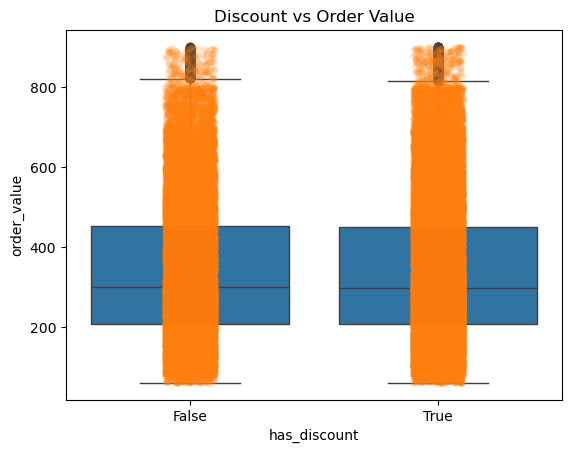

In [31]:
sns.boxplot(x='has_discount', y='order_value', data=df)
sns.stripplot(x='has_discount', y='order_value', data=df, alpha=0.2)
plt.title("Discount vs Order Value")
plt.show()

In [33]:
results = pd.DataFrame({
    'Test': ['Conversion','Order Value','Repeat Purchase','ANOVA'],
    'P-Value': [p, p_val, p_repeat, p_anova]
})

results.to_csv("ab_test_results.csv", index=False)
results

,Test,P-Value
0,Conversion,5.618304e-01
1,Order Value,1.590612e-01
2,Repeat Purchase,1.347083e-146
3,ANOVA,1.089458e-01
